# Joint configuration generator

In order to move the robot from A to B etc. we need to translate a position in the cartisan coordinate system into joint placement/configuration. In order to do this, we're gonna utilize the `roboticstoolbox`. The toolbox provide a number of features including forward- and inverse kinematics. With these we can input a $[x,y,z,r_x,r_y,r_z]$ and output a joint configuration $q_{target}[6]$ which can be send to the robot controller. In addtion, the controller will need the maximum joint velocity and acceleration provided.

## Initializing robot parameters for model

First we're gonna initialize the model needed to produce the configuration. 
The parameters are located from the website for the **Universal robot**

https://www.universal-robots.com/articles/ur/application-installation/dh-parameters-for-calculations-of-kinematics-and-dynamics/#:~:text=0.0000%2C%200.0000%2C%200.0012%5D-,UR3e,-Kinematics

In [1]:
%%writefile joint_config.py
from typing import Any

import roboticstoolbox as rtb
import numpy as np
from roboticstoolbox.robot import IKSolution
from spatialmath import SE3
from communication import protocol
from communication.rabbitmq import Rabbitmq

class Controller:
    
    def __init__(self):
        # Joint parameters
        self.vel = 60
        self.acc = 80
        self.links = [
            rtb.RevoluteDH(d = 0.15185, a = 0,        alpha = np.pi/2),
            rtb.RevoluteDH(d = 0,       a = -0.2435, alpha = 0),
            rtb.RevoluteDH(d = 0,       a = -0.2132,  alpha = 0),
            rtb.RevoluteDH(d = 0.13105, a = 0,        alpha = np.pi/2),
            rtb.RevoluteDH(d = 0.08535, a = 0,        alpha = -np.pi/2),
            rtb.RevoluteDH(d = 0.0921,  a = 0,        alpha = 0)
        ]
        self.configuration: IKSolution
        # Create the robot object
        self.robot = rtb.DHRobot(self.links, name="UR3e")
        
        # Messages
        self.rmq = Rabbitmq
        self.msg = {str, Any}
        

    # Generate configuration based on presets
    def generate_configuration_presets(self,preset: int):
        """
        Choose preset 1 - 3 
        1: [-0.4, -0.35, 0.1]
        2: [0.4, -0.2, 0.1]
        3: [0.15, -0.2, 0.40]
        """
        # assert (1 <= preset and preset <= 3), "Preset not available"
        
        
        match preset:
            case 1:
                self.generate_configuration(-0.4, -0.35, 0.1)
            case 2:
                self.generate_configuration(0.4, -0.2, 0.1)
            case 3:
                self.generate_configuration(0.15, -0.2, 0.40)
            case _:
                print("Preset not available")
                
        
    # Generate a joint configuration with xyz
    def generate_configuration(self,x: float, y: float, z: float, v_max=1, alpha_pt=1):
        # Verify inputs
        assert (-0.5 < x and x < 0.5), "x is outside range acceptable range [-0.5, 0.5]"
        assert (-0.5 < y and y < 0.5), "y is outside range acceptable range [-0.5, 0.5]"
        assert (-0.5 < z and z < 0.5), "z is outside range acceptable range [-0.5, 0.5]"
        
        # Rotation matrix
        # R = np.array([
        #     [1, 0, 0],
        #     [0, -1, 0],
        #     [0, 0, -1]
        # ])
        R = np.array([
            [1, 0, 0],
            [0, 1, 0],
            [0, 0, 1]
        ])
        
        # Setup matrix
        T = np.eye(4)
        T[:3,:3] = R
        T[:3,3] = [x,y,z]
        
        # Calculate joint configuration
        # print("Configuration: \n",T)
        configuration = self.robot.ikine_LM(T)
        
        # Verify correctness
        configuration_check = self.robot.fkine(configuration.q)  
        # print("\nConfiguration check: \n",configuration_check)
        assert (T.transpose()[3,:3] == np.round(configuration_check.t,3)).all(), f"Could not generate configuration for inputs"
        
        # Update configuration
        # print(f"Configuration: \n{configuration}\n")
        self.configuration = configuration
    
    def connect_to_broker(self):
        try:
            self.rmq = Rabbitmq(
                ip="localhost",
                port=5672,
                username="ur3e",
                password="ur3e",
                vhost="/",
                exchange="UR3E_AMQP",
                type="topic",
            )
            self.rmq.connect_to_server()
            print("✓ Connected to RabbitMQ successfully")
        except Exception as e:
            print(f"✗ Failed to connect to RabbitMQ: {e}")
            print("\nMake sure RabbitMQ is running. You can start it with:")
            print("  python -m startup.start_docker_rabbitmq")

    # define a callback function to handle received messages
    def on_message_received(ch, method, properties, body):
        try:
            print("✓ State:")
            print(body)
        except Exception as e:
            print(f"✗ Failed to decode the message: {e}")    
            
    def send_control_message(self,rmq, msg):
        """Send a control message to the UR3e Mockup via RabbitMQ."""
        try:
            self.rmq.send_message(
                routing_key=protocol.ROUTING_KEY_CTRL,
                message=msg
            )
            print(f"✓ Control message: {msg} sent successfully")
        except Exception as e:
            print(f"✗ Failed to send control message: {e}")
        
    def send_data(self):
        """"""
        # Generate msg
        msg = {
                protocol.CtrlMsgKeys.TYPE: protocol.CtrlMsgFields.LOAD_PROGRAM,
                protocol.CtrlMsgKeys.JOINT_POSITIONS: self.configuration.q.tolist(),
                protocol.CtrlMsgKeys.MAX_VELOCITY: self.vel,
                protocol.CtrlMsgKeys.ACCELERATION: self.acc,
        }

        self.send_control_message(self.rmq, msg)
        
        # send control message for starting program
        msg_start = {
            protocol.CtrlMsgKeys.TYPE: protocol.CtrlMsgFields.PLAY,
        }
        
        self.send_control_message(self.rmq, msg_start)

    def operation(self):     
        while True:
            print("\n\n*** PRESETS ***\n1: [-0.4, -0.35, 0.1]\n2: [0.4, -0.2, 0.1]\n3: [0.15, -0.2, 0.40]\n")
            user_input = input("Enter preset: ").strip().lower()
            
            if (1 <= int(user_input) and int(user_input) <= 3): 
                self.generate_configuration_presets(int(user_input))
                user_input = ""
                self.send_data()

            
    def operation_test(self):
        self.generate_configuration_presets(1)
        self.send_data()
        

if __name__ == "__main__":
    controller = Controller()
    controller.connect_to_broker()
    controller.operation()

Overwriting joint_config.py


# Simulations

In [ ]:
# Import the controller
from joint_config import Controller
armController = Controller()

# Setup
# print(armController.robot)

# Caluculate different q for the same T (location?)
armController.generate_configuration_presets(1)
T1 = armController.configuration
armController.generate_configuration_presets(1)
T2 = armController.configuration
print(T1)
print(T2)

# armController.robot.plot()
# armController.robot.plot()

IKSolution: q=[-2.174, 2.702, 0.2485, -1.38, -1.571, 0.6028], success=True, iterations=43, searches=2, residual=1.73e-07
IKSolution: q=[0.4697, 0.4392, -0.2485, -1.761, 1.571, 1.101], success=True, iterations=77, searches=3, residual=1.81e-07


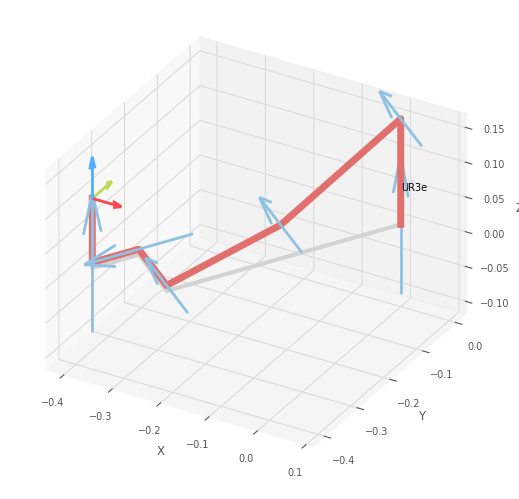

<Figure size 640x480 with 0 Axes>

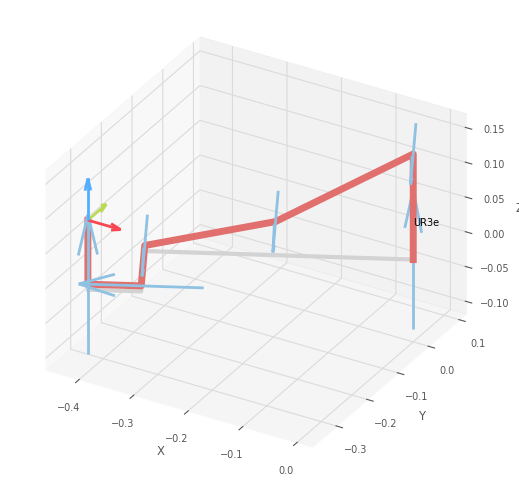

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'UR3e')

<Figure size 640x480 with 0 Axes>

In [ ]:
armController.robot.plot(T1.q)
armController.robot.plot(T2.q)